In [1]:
# imports + access utils from parent folder
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from utils import load_ct_series

In [2]:
# loading CT image
# quick sanity check so we know data is valid

ct_image = load_ct_series("./sample.dcm")

print("Shape:", ct_image.shape)
print("Mean HU:", np.mean(ct_image))

Shape: (512, 512)
Mean HU: -870.2389602661133


In [3]:
# applying lung window
# without this, CT looks flat and unreadable

def ct_window(image, level=-600, width=1500):
    min_val = level - width // 2
    max_val = level + width // 2
    
    image = np.clip(image, min_val, max_val)
    return (image - min_val) / (max_val - min_val)

In [4]:
# Lung Segmentation Cell (final stable version)

# goal:
# isolate lung regions from CT using HU thresholds + spatial + size filtering

from scipy.ndimage import binary_opening, binary_closing, binary_fill_holes, label

# step 1: identify air-like regions
# lung pixels fall in this HU range, rest is mostly tissue/bone
lung_mask = (ct_image < -400) & (ct_image > -1000)

# step 2: remove small noise
# prevents random pixels from being treated as lung
lung_mask = binary_opening(lung_mask, structure=np.ones((3, 3)))

# step 3: smooth boundaries
# makes mask more stable and continuous
lung_mask = binary_closing(lung_mask, structure=np.ones((5, 5)))

# step 4: fill internal gaps
# ensures lung regions are solid, not hollow
lung_mask = binary_fill_holes(lung_mask)

# step 5: label connected regions
# separates different components in the mask
labeled_mask, num_regions = label(lung_mask)

# step 6: compute size of each region
region_sizes = [(labeled_mask == i).sum() for i in range(1, num_regions + 1)]

# step 7: keep only meaningful regions
# removes large background leakage while keeping lung regions intact
min_size = np.max(region_sizes) * 0.2

valid_regions = [
    i + 1 for i, size in enumerate(region_sizes) if size > min_size
]

# step 8: build initial clean mask
clean_mask = np.isin(labeled_mask, valid_regions)

# step 9: remove lower-body artifacts (table / abdomen)
# lungs sit in upper region → bottom not needed
h, w = clean_mask.shape

upper_region_mask = np.zeros_like(clean_mask)
upper_region_mask[:int(h * 0.75), :] = 1

clean_mask = clean_mask & upper_region_mask

# step 10: remove boundary regions (outer chest ring)
# lungs are central → edges mostly contain non-lung structures
center_mask = np.zeros_like(clean_mask)

margin_h = int(h * 0.15)
margin_w = int(w * 0.12)

center_mask[
    margin_h : h - margin_h,
    margin_w : w - margin_w
] = 1

clean_mask = clean_mask & center_mask

# step 11: remove tiny leftover patches
# keeps only significant connected regions
labeled_final, num_final = label(clean_mask)

final_sizes = [(labeled_final == i).sum() for i in range(1, num_final + 1)]

min_final_size = np.max(final_sizes) * 0.2

valid_final = [
    i + 1 for i, size in enumerate(final_sizes) if size > min_final_size
]

clean_mask = np.isin(labeled_final, valid_final)

# step 12: extract final lung region
lung_region = ct_image * clean_mask

print("Segmentation complete")

Segmentation complete


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

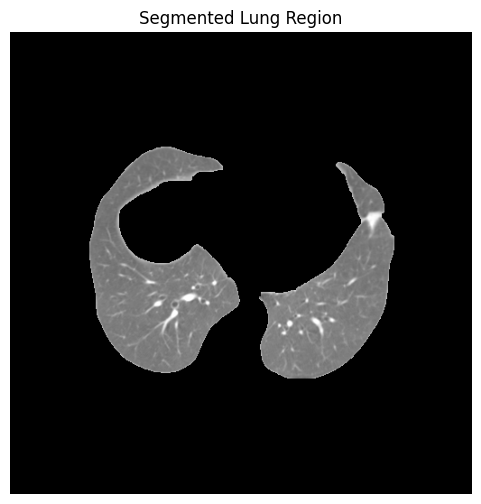

In [5]:
# visualization -- Hero Cell
# show only lung region clearly
# window first, then mask (otherwise contrast breaks)

windowed_image = ct_window(ct_image)

lung_display = (windowed_image * clean_mask) ** 0.6

plt.figure(figsize=(6,6))
plt.imshow(lung_display, cmap="gray")
plt.title("Segmented Lung Region")
plt.axis("off")

In [6]:
# extracting clean lung features (final stable version)

# directly use mask to pick only lung region
lung_pixels = ct_image[clean_mask]

# restrict to realistic lung HU range
lung_pixels = lung_pixels[(lung_pixels < -500) & (lung_pixels > -950)]

if lung_pixels.size == 0:
    print("No valid lung pixels detected")
else:
    # normalized lung density
    lung_density = np.mean(lung_pixels) / -1000

    # proportion of very low-density (air-heavy) regions
    low_density_ratio = np.sum(lung_pixels < -700) / lung_pixels.size

    print("Lung Density:", lung_density)
    print("Low Density Ratio:", low_density_ratio)

Lung Density: 0.8544741451441958
Low Density Ratio: 0.9359346237518826


In [7]:
# simple risk interpretation
# combining air exposure + lung condition

aqi = 180
exposure_hours = 6

exposure_score = aqi * exposure_hours

risk_score = exposure_score * (1 + low_density_ratio) * (1 + lung_density)

print("Final Risk Score:", risk_score)

Final Risk Score: 3877.351962952309
